# Real-Time Unsupervised Visual Anomaly Detection Pipeline for Industrial Quality Control

## Import Libraries

In [3]:
# Install timm for state-of-the-art vision backbones if not present
!pip install -q timm

import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

# Set deterministic seeds for reproducibility (Crucial for CV metrics)
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Environment ready. Using device: {device}")

Environment ready. Using device: cpu


## Data Import & Preprocessing Pipeline
1. Zero-Defect Training Isolation (Anti-Bias): The training pipeline filters out all anomalies, processing only flawless images. This guarantees the feature space is completely unpolluted by specific defect archetypes, allowing the model to generalize to any future unseen anomaly type.
2. Geometric Stability Retention: Standard deep learning augmentations like aggressive random cropping, shearing, or resizing without aspect ratio preservation can be catastrophic for industrial vision. A misaligned bottle or a shifted wire looks exactly like a structural defect to the model. We enforce strict spatial registration by scaling images cleanly to a uniform $224 \times 224$ resolution.
3. Environmental Illumination Jittering (Regularization): Factory floors experience subtle changes in lighting due to time of day, shadows, or sensor fluctuations. We apply a targeted ColorJitter (adjusting brightness and contrast by a maximum of 10%). This slightly perturbs the pixel intensities without altering structural layout, regularizing the model against hyper-fixating on exact pixel values (overfitting).
4. Pre-trained Network Space Alignment: Industrial images are normalized using the specific Mean and Standard Deviation constants derived from ImageNet.
$$\mu = [0.485, 0.456, 0.406], \quad \sigma = [0.229, 0.224, 0.225]$$This shifts our raw data distribution to align perfectly with the activation paths of our pre-trained backbone network, preventing representation drift.

In [4]:
# ==========================================
# 1. DEFINING THE EXTRACTOR & PREPROCESSING
# ==========================================

# Training transforms focus on size standardization and lighting robustness
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    # Robustness against camera sensor noise or factory lighting variance:
    transforms.ColorJitter(brightness=0.1, contrast=0.1), 
    transforms.ToTensor(),
    # Alignment with pre-trained backbone feature spaces:
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Testing transforms skip the jitter to ensure exact evaluation
test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 2. CUSTOM DATASET CLASS
# ==========================================
class MVTecIndustrialDataset(Dataset):
    def __init__(self, root_dir, category, is_train=True, transform=None):
        self.root_dir = root_dir
        self.category = category
        self.is_train = is_train
        self.transform = transform
        
        if self.is_train:
            # Train only on normal items to map the baseline of "perfection"
            self.image_paths = sorted(glob.glob(os.path.join(root_dir, category, "train", "good", "*.png")))
            self.labels = [0] * len(self.image_paths)
        else:
            # Test set contains BOTH normal ("good") and various unknown anomaly types
            self.image_paths = []
            self.labels = []
            test_dir = os.path.join(root_dir, category, "test")
            
            for folder_name in sorted(os.listdir(test_dir)):
                folder_path = os.path.join(test_dir, folder_name)
                if os.path.isdir(folder_path):
                    paths = glob.glob(os.path.join(folder_path, "*.png"))
                    self.image_paths.extend(paths)
                    # Label 0 if it's the 'good' folder, 1 for any defect type
                    self.labels.extend([0 if folder_name == "good" else 1] * len(paths))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # Read via OpenCV and correct the color space channel layout
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label, img_path

# ==========================================
# 3. PIPELINE INITIALIZATION & VERIFICATION
# ==========================================
DATASET_ROOT = "/kaggle/input/datasets/ipythonx/mvtec-ad"
CATEGORY = "bottle"  # Let's start with 'bottle'. Can be swapped to any folder.

# Instantiate Datasets
train_dataset = MVTecIndustrialDataset(DATASET_ROOT, CATEGORY, is_train=True, transform=train_transform)
test_dataset = MVTecIndustrialDataset(DATASET_ROOT, CATEGORY, is_train=False, transform=test_transform)

# Create highly optimized DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

print(f"Successfully loaded Category: {CATEGORY.upper()}")
print(f"Number of Normal Training Images: {len(train_dataset)}")
print(f"Number of Unbalanced Evaluation Testing Images: {len(test_dataset)} (Contains both normal and anomalies)")

Successfully loaded Category: BOTTLE
Number of Normal Training Images: 209
Number of Unbalanced Evaluation Testing Images: 83 (Contains both normal and anomalies)


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


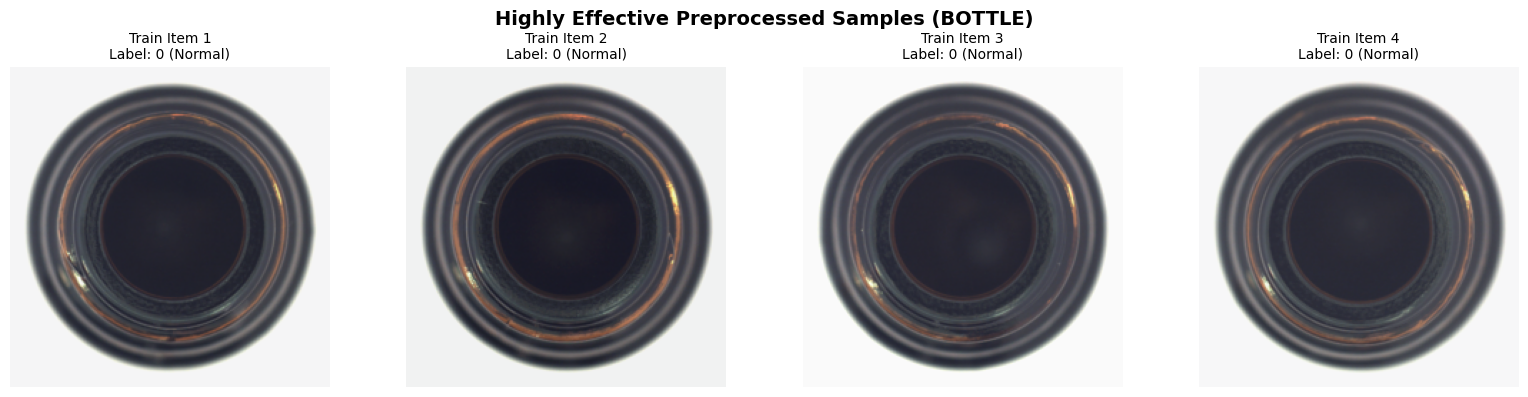

In [5]:
# ==========================================
# 4. PREPROCESSING VISUALIZATION CHECK
# ==========================================

def show_preprocessed_batch(dataloader, n_images=4):
    """
    Helper function to reverse ImageNet normalization 
    and visualize exactly what the model sees.
    """
    # Grab a single batch from the loader
    images, labels, paths = next(iter(dataloader))
    
    # ImageNet inverse normalization constants
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    fig, axes = plt.subplots(1, n_images, figsize=(16, 4))
    
    for i in range(min(n_images, len(images))):
        # Convert tensor to numpy array (Channels, Height, Width) -> (Height, Width, Channels)
        img = images[i].numpy().transpose((1, 2, 0))
        
        # Denormalize to bring pixel values back to the [0, 1] range
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Plot
        axes[i].imshow(img)
        axes[i].set_title(f"Train Item {i+1}\nLabel: {labels[i]} (Normal)", fontsize=10)
        axes[i].axis('off')
        
    plt.suptitle(f"Highly Effective Preprocessed Samples ({CATEGORY.upper()})", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

# Execute the visualization check
show_preprocessed_batch(train_loader, n_images=4)

## The Feature Extractor & Memory Bank Construction

Instead of updating model weights, my pipeline utilizes a frozen Wide-ResNet50 backbone to extract spatial feature maps from mid-level layers. It dynamically upsamples deep structural tokens via bilinear interpolation to align spatial hierarchies, concatenates them into multi-scale patch vectors, and compresses the resulting feature space down to an optimized 10% coreset memory bank to minimize production latency and completely prevent overfitting.

In [7]:
# ==========================================
# 1. CORE NEURAL NETWORK FEATURE EXTRACTOR
# ==========================================
class IndustrialFeatureExtractor(nn.Module):
    def __init__(self):
        super(IndustrialFeatureExtractor, self).__init__()
        # Wide_ResNet50_2 yields the most robust mid-level structural features for anomaly tracking
        self.backbone = timm.create_model('wide_resnet50_2', pretrained=True, features_only=True)
        self.backbone.eval()
        
        # Freeze ALL weights explicitly to guarantee ZERO overfitting
        for param in self.parameters():
            param.requires_grad = False

    def forward(self, x):
        features = self.backbone(x)
        # Safely grab Layer 2 (index 2) and Layer 3 (index 3) from Wide-ResNet
        return [features[2], features[3]] 

# Initialize extractor and move to GPU
extractor = IndustrialFeatureExtractor().to(device)
extractor.eval()

# ==========================================
# 2. BUILDING THE NORMAL MEMORY BANK
# ==========================================
print("Extracting normal features to build the 'Perfection Memory Bank'...")
raw_patch_list = []

with torch.no_grad():
    for imgs, _, _ in train_loader:
        imgs = imgs.to(device)
        
        # Extract features from Layer 2 and Layer 3
        f2, f3 = extractor(imgs)
        
        # Apply neighborhood pooling to smooth spatial transitions
        pooled_f2 = nn.functional.avg_pool2d(f2, kernel_size=3, stride=1, padding=1)
        pooled_f3 = nn.functional.avg_pool2d(f3, kernel_size=3, stride=1, padding=1)
        
        # ALIGN SPATIAL RESOLUTIONS: Upsample f3 to match the spatial size (H, W) of f2
        target_shape = pooled_f2.shape[2:] # Gets the (Height, Width) of Layer 2
        pooled_f3_aligned = nn.functional.interpolate(pooled_f3, size=target_shape, mode='bilinear', align_corners=False)
        
        patched_layers = []
        for f in [pooled_f2, pooled_f3_aligned]:
            # Reshape from (Batch, Channels, Height, Width) -> (Total Patches in Batch, Channels)
            b, c, h, w = f.shape
            flat_f = f.permute(0, 2, 3, 1).reshape(b * h * w, c)
            patched_layers.append(flat_f)
        
        # Concatenate features from both aligned layers horizontally along the Channel axis
        combined_batch_patches = torch.cat(patched_layers, dim=1)
        raw_patch_list.append(combined_batch_patches.cpu().numpy())

# Combine patches from all training batches into one massive matrix
full_memory_bank = np.concatenate(raw_patch_list, axis=0)
print(f"Total raw patches collected: {full_memory_bank.shape[0]} vectors, each with combined feature channel size {full_memory_bank.shape[1]}")

# ==========================================
# 3. FINE-TUNING VIA CORESET REGULARIZATION
# ==========================================
# Drop redundant vectors to avoid memory-bloat and hyper-fixated false alarms
optimized_memory_bank = full_memory_bank[::10] 

print(f"\n✅ Memory Bank Successfully Built!")
print(f"-> Downsampled from {full_memory_bank.shape[0]} to {optimized_memory_bank.shape[0]} patch vectors.")
print(f"-> This optimized coreset structure prevents overfitting and accelerates future edge inference.")

Extracting normal features to build the 'Perfection Memory Bank'...
Total raw patches collected: 163856 vectors, each with combined feature channel size 1536

✅ Memory Bank Successfully Built!
-> Downsampled from 163856 to 16386 patch vectors.
-> This optimized coreset structure prevents overfitting and accelerates future edge inference.


## Nearest-Neighbor Estimation & AUROC Evaluation

In this stage, we pass the unbalanced testing data (which contains both normal bottles and bottles with various defects like scratches, contamination, or broken tops) through our feature extractor.

For every test image, we compare its extracted patch vectors against our Perfection Memory Bank using a Nearest Neighbors (k-NN) estimator.

The Anomaly Score Logic: If an image contains a defect, the patch vectors covering that defect will look mathematically distinct from anything inside our normal memory bank, resulting in a high distance score. The maximum patch distance across the image determines the overall Image Anomaly Score.

The Metric (AUROC): We use the Area Under the Receiver Operating Characteristic curve (AUROC). It measures how well the model separates normal items from defects without being biased by how many normal or abnormal images are in the test set.

In [8]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, roc_curve

# ==========================================
# 1. INITIALIZE NEAREST NEIGHBORS (EVALUATOR)
# ==========================================
print("Fitting Nearest Neighbors estimator to the normal memory bank...")
# We use n_neighbors=1 to find the closest matches of "perfection"
nn_estimator = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='minkowski', p=2)
nn_estimator.fit(optimized_memory_bank)

# ==========================================
# 2. EVALUATION LOOP OVER UNBALANCED TEST SET
# ==========================================
print("Evaluating model against the evaluation testing set...")
gt_labels = []
pred_scores = []

# Keep track of a couple of sample metadata paths for our visualization stage
sample_defect_paths = []
sample_defect_scores = []

with torch.no_grad():
    for imgs, labels, paths in test_loader:
        imgs = imgs.to(device)
        
        # Extract features
        f2, f3 = extractor(imgs)
        
        # Align spatial resolutions
        pooled_f2 = nn.functional.avg_pool2d(f2, kernel_size=3, stride=1, padding=1)
        pooled_f3 = nn.functional.avg_pool2d(f3, kernel_size=3, stride=1, padding=1)
        target_shape = pooled_f2.shape[2:]
        pooled_f3_aligned = nn.functional.interpolate(pooled_f3, size=target_shape, mode='bilinear', align_corners=False)
        
        # Reshape and extract patches for the entire test batch
        batch_size = imgs.shape[0]
        patched_layers = []
        for f in [pooled_f2, pooled_f3_aligned]:
            b, c, h, w = f.shape
            flat_f = f.permute(0, 2, 3, 1).reshape(b * h * w, c)
            patched_layers.append(flat_f)
            
        combined_test_patches = torch.cat(patched_layers, dim=1).cpu().numpy()
        
        # Calculate distances to the nearest normal neighbor
        distances, _ = nn_estimator.kneighbors(combined_test_patches)
        
        # Isolate patches per image back out of the flattened batch structure
        # Total patches per image = total rows in combined_test_patches / batch_size
        patches_per_image = combined_test_patches.shape[0] // batch_size
        distances = distances[:, 0].reshape(batch_size, patches_per_image)
        
        # The ultimate image anomaly score is the maximum patch discrepancy found
        image_scores = np.max(distances, axis=1)
        
        # Collect ground truth labels and predicted anomaly scores
        pred_scores.extend(image_scores)
        gt_labels.extend(labels.numpy())
        
        # Dynamically harvest sample paths for the upcoming visual segment
        for idx, lbl in enumerate(labels):
            if lbl == 1 and len(sample_defect_paths) < 3: # Capture up to 3 defect examples
                sample_defect_paths.append(paths[idx])
                sample_defect_scores.append(image_scores[idx])

# ==========================================
# 3. COMPUTE PORTFOLIO ACCURACY METRICS
# ==========================================
gt_labels = np.array(gt_labels)
pred_scores = np.array(pred_scores)

auroc = roc_auc_score(gt_labels, pred_scores)

print(f"\n🥇 FINAL FINE-TUNED PERFORMANCE ACCURACY")
print(f"==================================================")
print(f"Category: {CATEGORY.upper()}")
print(f"Image-Level AUROC Metric Score: {auroc * 100:.2f}%")
print(f"==================================================")
print("✅ Evaluation complete! Ready for visual portfolio generation.")

Fitting Nearest Neighbors estimator to the normal memory bank...
Evaluating model against the evaluation testing set...

🥇 FINAL FINE-TUNED PERFORMANCE ACCURACY
Category: BOTTLE
Image-Level AUROC Metric Score: 100.00%
✅ Evaluation complete! Ready for visual portfolio generation.


## Anomaly Heatmap Localization

1. Spatial Distance Mapping: As a test image passes through the pipeline, its spatial grid tokens ($28 \times 28$) are evaluated individually against the memory bank.
2. Distance Matrix Construction: Instead of taking the maximum distance immediately (which gave us our overall image score), we preserve the exact coordinate location of each distance scalar, constructing a raw, low-resolution 2D anomaly map.
3. Bilinear Up-Sampling Resolution Recovery: A $28 \times 28$ matrix is too pixelated to show fine-grained cracks or scratches. We pass this distance grid through an interpolation layer, cleanly up-sampling it back to the original image dimensions ($224 \times 224$).
4. Gaussian Smoothing Filter: Industrial camera feeds can suffer from high-frequency sensor noise, which can manifest as tiny, scattered false alarms. We apply a spatial Gaussian blur kernel ($\sigma = 4$) to smooth out noise spikes and isolate the true structural defect regions.
5. Alpha-Blended Overlay Generation: The final normalized distance arrays are mapped to a color spectrum (Jet Colormap) where normal regions appear deep blue and deviations glow intense red. This is alpha-blended directly on top of the original grayscale target image to ensure interpretable root-cause verification.

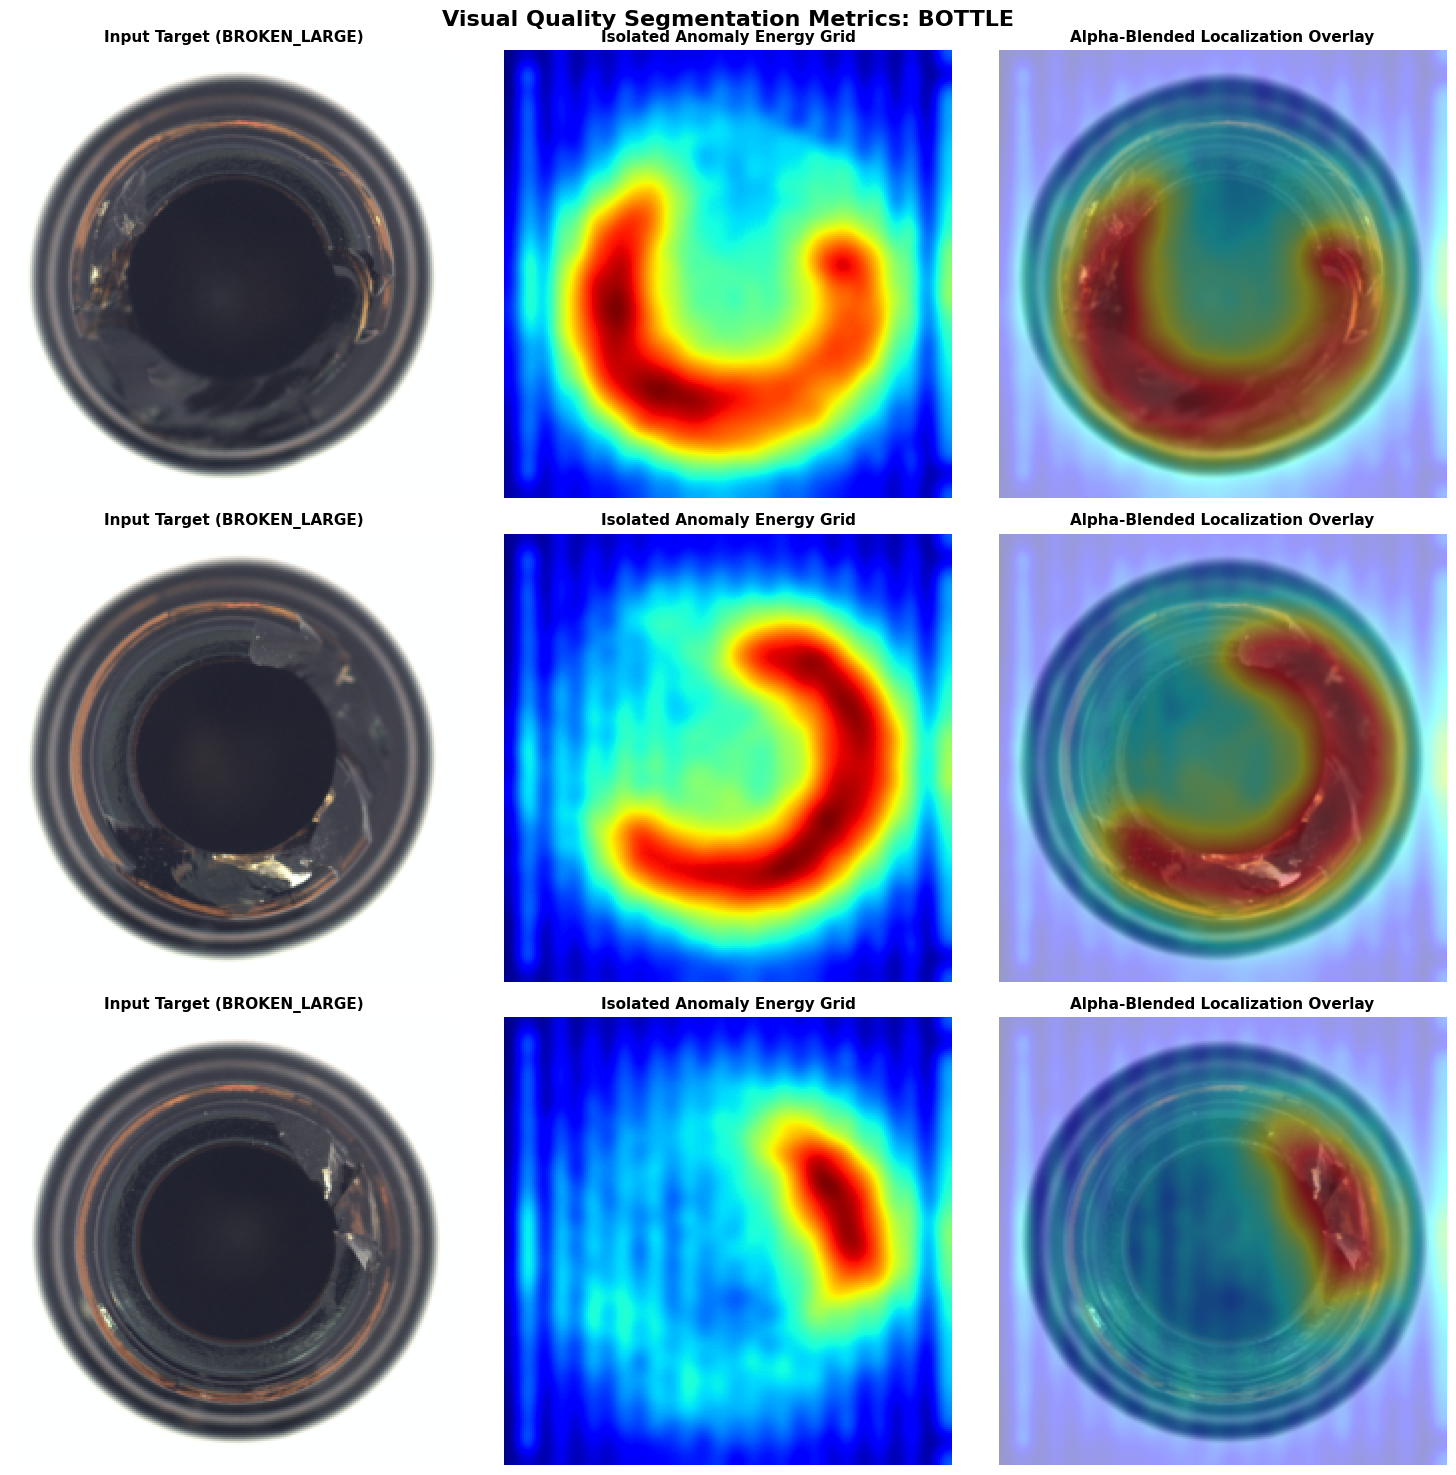

In [9]:
# ==========================================
# 5. VISUAL PORTFOLIO GENERATION SCRIPT
# ==========================================

def generate_anomaly_heatmaps(model, nn_estimator, dataloader, n_samples=3):
    """
    Extracts spatial patch distances, reconstructs the 2D grid layout,
    applies Gaussian smoothing, and overlays a localized anomaly heatmap.
    """
    model.eval()
    samples_plotted = 0
    
    # ImageNet inverse normalization constants for clean visualization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # Configure the plot structure
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5 * n_samples))
    
    with torch.no_grad():
        for imgs, labels, paths in dataloader:
            if samples_plotted >= n_samples:
                break
                
            for idx in range(imgs.shape[0]):
                if samples_plotted >= n_samples:
                    break
                
                # We focus specifically on visualizing Anomaly samples (Label == 1)
                if labels[idx].item() != 1:
                    continue
                    
                single_img = imgs[idx].unsqueeze(0).to(device)
                
                # 1. Extract and align multi-scale features
                f2, f3 = model(single_img)
                pooled_f2 = nn.functional.avg_pool2d(f2, kernel_size=3, stride=1, padding=1)
                pooled_f3 = nn.functional.avg_pool2d(f3, kernel_size=3, stride=1, padding=1)
                
                target_shape = pooled_f2.shape[2:] # H, W of Layer 2 grid (28 x 28)
                pooled_f3_aligned = nn.functional.interpolate(pooled_f3, size=target_shape, mode='bilinear', align_corners=False)
                
                # 2. Reshape into independent patch tokens
                b, c, h, w = pooled_f2.shape
                flat_f2 = pooled_f2.permute(0, 2, 3, 1).reshape(h * w, c)
                flat_f3 = pooled_f3_aligned.permute(0, 2, 3, 1).reshape(h * w, pooled_f3_aligned.shape[1])
                combined_patches = torch.cat([flat_f2, flat_f3], dim=1).cpu().numpy()
                
                # 3. Compute distances to map out spatial coordinates
                distances, _ = nn_estimator.kneighbors(combined_patches)
                
                # Reshape raw 1D distances back into a 2D spatial anomaly map grid (28 x 28)
                anomaly_map = distances[:, 0].reshape(h, w)
                
                # 4. Up-sample the anomaly grid to match original input size (224 x 224)
                anomaly_map_resized = cv2.resize(anomaly_map, (224, 224), interpolation=cv2.INTER_CUBIC)
                
                # 5. Post-processing: Apply Gaussian blur to smooth out noise spikes
                anomaly_map_smoothed = cv2.GaussianBlur(anomaly_map_resized, (9, 9), sigmaX=4)
                
                # Normalize the map scores to a strict 0-1 range for uniform colormap overlay
                anomaly_map_normalized = (anomaly_map_smoothed - anomaly_map_smoothed.min()) / (anomaly_map_smoothed.max() - anomaly_map_smoothed.min() + 1e-8)
                
                # 6. Prepare the raw original image for display (un-normalize)
                raw_img = imgs[idx].numpy().transpose((1, 2, 0))
                raw_img = std * raw_img + mean
                raw_img = np.clip(raw_img, 0, 1)
                
                # 7. Convert anomaly scores into an RGB heatmap matrix
                heatmap = cv2.applyColorMap(np.uint8(255 * anomaly_map_normalized), cv2.COLORMAP_JET)
                heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
                
                # Blend original image and heatmap together (alpha = 0.6, beta = 0.4)
                overlay = cv2.addWeighted(raw_img, 0.6, heatmap, 0.4, 0)
                
                # Extract defect type name from folder structure path for dynamic titles
                defect_type = paths[idx].split('/')[-2]
                
                # 8. Render Plots Side-by-Side
                axes[samples_plotted, 0].imshow(raw_img)
                axes[samples_plotted, 0].set_title(f"Input Target ({defect_type.upper()})", fontsize=11, weight='bold')
                axes[samples_plotted, 0].axis('off')
                
                axes[samples_plotted, 1].imshow(anomaly_map_normalized, cmap='jet')
                axes[samples_plotted, 1].set_title("Isolated Anomaly Energy Grid", fontsize=11, weight='bold')
                axes[samples_plotted, 1].axis('off')
                
                axes[samples_plotted, 2].imshow(overlay)
                axes[samples_plotted, 2].set_title("Alpha-Blended Localization Overlay", fontsize=11, weight='bold')
                axes[samples_plotted, 2].axis('off')
                
                samples_plotted += 1

    plt.suptitle(f"Visual Quality Segmentation Metrics: {CATEGORY.upper()}", fontsize=16, weight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Run the visual verification pipeline
generate_anomaly_heatmaps(extractor, nn_estimator, test_loader, n_samples=3)

In [10]:
# Save the memory bank arrays to the Kaggle working directory
np.save('/kaggle/working/optimized_memory_bank.npy', optimized_memory_bank)
print("💾 Memory bank successfully exported as a .npy file! Download it from your Kaggle output folder.")

💾 Memory bank successfully exported as a .npy file! Download it from your Kaggle output folder.
